## Goals:
- Understand what correlation means.
- Learn Pearson vs Spearman correlation.
- Calculate correlation matrix.
- Visualize relationships using heatmap and pairplot.

## Correlation
- Measures how strongly two variables move together.

| Type         | Meaning                            | Example             |
| ------------ | ---------------------------------- | ------------------- |
| **Positive** | both increase together             | height & weight     |
| **Negative** | one increases, the other decreases | speed & travel time |
| **Zero**     | no relationship                    | shoe size & IQ      |

## Pearson vs Spearman

## Pearson
- measures linear correlation. (default in df.corr()).

## Spearman
- measures rank-based(monotonic) correlation. (less affected by outliers).

## Calculate Correlation in Python

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file = r"C:\Users\hp\OneDrive\Documents\Data Analysis and Visualization Expertise\Extracted_Files\5-Days-Live-EDA-and-Feature-Engineering-main\Zomato_Dataset\zomato.csv"
df = pd.read_csv(file,encoding='latin-1')

# Assuming df is your cleaned dataset.
pearson_corr = df.corr(numeric_only=True) #default

spearman_corr = df.corr(numeric_only=True,method='spearman')

# Display top of each
print("Pearson Correlation:\n",pearson_corr.head())
print("\nSpearman Correlation:\n",spearman_corr.head())

Pearson Correlation:
                       Restaurant ID  Country Code  Longitude  Latitude  \
Restaurant ID              1.000000      0.148471  -0.226081 -0.052081   
Country Code               0.148471      1.000000  -0.698299  0.019792   
Longitude                 -0.226081     -0.698299   1.000000  0.043207   
Latitude                  -0.052081      0.019792   0.043207  1.000000   
Average Cost for two      -0.001693      0.043225   0.045891 -0.111088   

                      Average Cost for two  Price range  Aggregate rating  \
Restaurant ID                    -0.001693    -0.134540         -0.326212   
Country Code                      0.043225     0.243327          0.282189   
Longitude                         0.045891    -0.078939         -0.116818   
Latitude                         -0.111088    -0.166688          0.000516   
Average Cost for two              1.000000     0.075083          0.051792   

                         Votes  
Restaurant ID        -0.147023  
Coun

## Visualize Correlation with Heatmaps

| Correlation Value | Meaning                                        |
| ----------------- | ---------------------------------------------- |
| **+1.0**          | Perfect positive correlation (move together)   |
| **0.0**           | No correlation                                 |
| **−1.0**          | Perfect negative correlation (move oppositely) |

Example:

0.68 → moderately strong positive correlation

0.10 → weak correlation

−0.75 → strong negative correlation

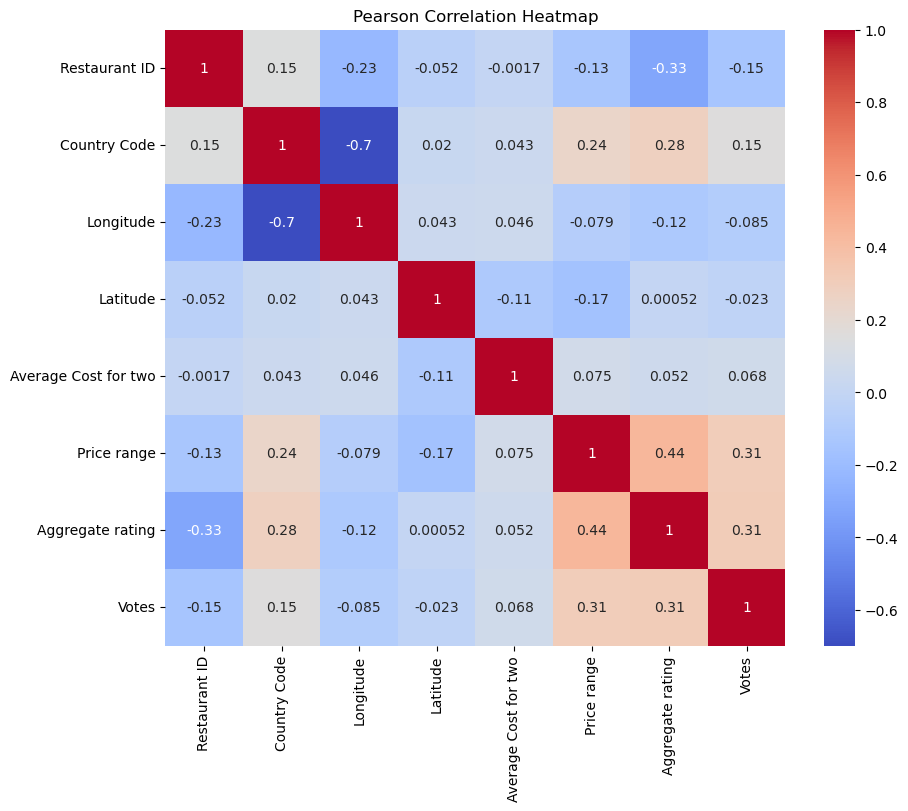

In [2]:
plt.figure(figsize=(10,8))
sns.heatmap(pearson_corr,annot=True,cmap='coolwarm') 
# annot=True - Shows actual correlation values.
# cmpa='coolwarm' - Colors negative(blue) to positive(red) correlations.
plt.title('Pearson Correlation Heatmap')
plt.show()

In [5]:
# Show pairs with strong correlation
strong_corr = pearson_corr[(pearson_corr > 0.6) & (pearson_corr < 1)]
strong_corr.dropna(how='all', inplace=True)
strong_corr

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes


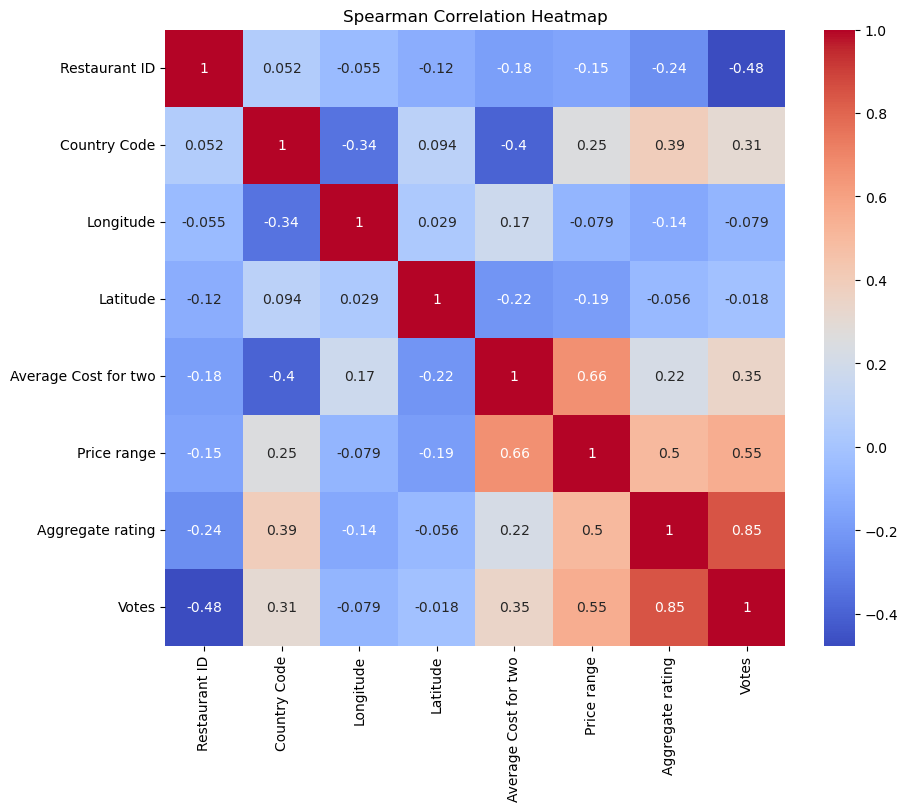

In [3]:
plt.figure(figsize=(10,8))
sns.heatmap(spearman_corr,annot=True,cmap='coolwarm') 
# annot=True - Shows actual correlation values.
# cmpa='coolwarm' - Colors negative(blue) to positive(red) correlations.
plt.title('Spearman Correlation Heatmap')
plt.show()

## Pairplot - To see relationships

Interpretation:

Tight upward lines = strong positive correlation

Scattered clouds = weak or no correlation

Downward lines = negative correlation

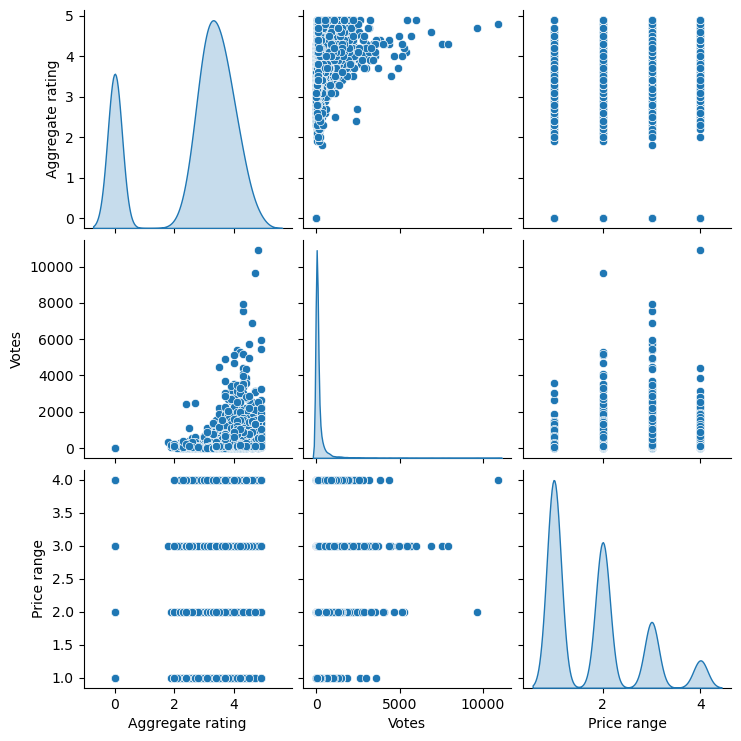

In [4]:
sns.pairplot(df[['Aggregate rating','Votes','Price range']],diag_kind='kde') 
# Each pair of numeric columns is plotted against each other.
# diag_kind='kde' - Adds smooth curves on the diagonal histograms.
# Helps us see trends, clusters and outliers.

plt.show()

## Summary

### Day 4 Summary — Correlation Analysis
- Correlation helps find how variables move together.
- Pearson is used for linear relationships, Spearman for rank-based ones.
- The heatmap shows the strength of relationships between numeric variables.
- Pairplots reveal visible patterns or clusters in the data.
- Example observation: Aggregate rating is positively correlated with Votes.